**Introduction**

Facial emotion recognition is an important application of deep learning in human-computer interaction.
This project uses a Convolutional Neural Network (CNN) to classify facial expressions into seven emotion categories: Angry, Disgust, Fear, Happy, Sad, Surprise, and Neutral.
The model is trained on grayscale facial images and evaluated using performance metrics, visualizations, and explainable AI techniques such as Grad-CAM.

Dataset Loaded: (21249, 3)
After cleaning: (21248, 4)
Image Shape: (21248, 48, 48, 1)
Labels Shape: (21248,)
Train shape: (16998, 48, 48, 1)
Validation shape: (4250, 48, 48, 1)


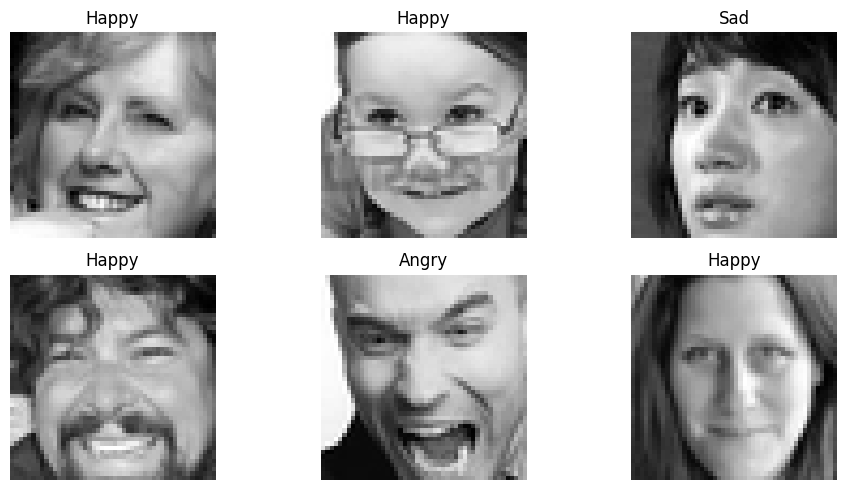

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Load Dataset
# -------------------------------
data = pd.read_csv('/content/fer2013.csv')  # update path if needed
print("Dataset Loaded:", data.shape)

# -------------------------------
# Step 2: Clean Data
# -------------------------------
# Remove missing values
data = data.dropna(subset=['pixels'])

# Convert to string
data['pixels'] = data['pixels'].astype(str)

# -------------------------------
# Step 3: Convert Pixels → Image (FIXED)
# -------------------------------
def process_pixels(pixels):
    pixels = pixels.strip()
    pixels = np.fromstring(pixels, sep=' ', dtype='float32')

    # Keep only valid images (48x48 = 2304 pixels)
    if pixels.size == 2304:
        return pixels.reshape(48, 48, 1)
    else:
        return None

# Apply conversion
data['image'] = data['pixels'].apply(process_pixels)

# Remove invalid rows
data = data.dropna(subset=['image'])

print("After cleaning:", data.shape)

# -------------------------------
# Step 4: Prepare Features & Labels
# -------------------------------
X = np.stack(data['image'].values)
y = data['emotion'].values

print("Image Shape:", X.shape)
print("Labels Shape:", y.shape)

# -------------------------------
# Step 5: Normalize Images
# -------------------------------
X = X / 255.0

# -------------------------------
# Step 6: Train-Test Split
# -------------------------------
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

# -------------------------------
# Step 7: Visualize Sample Images
# -------------------------------
emotion_labels = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Sad',
    5: 'Surprise',
    6: 'Neutral'
}

plt.figure(figsize=(10, 5))

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.title(emotion_labels[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Import deep learning libraries
import tensorflow as tf
from tensorflow.keras import layers, models

# ------------------------------------------
# Step 1: Build CNN Model
# ------------------------------------------
model = models.Sequential([

    # First Convolution Block
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    layers.MaxPooling2D(2,2),

    # Second Convolution Block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Third Convolution Block
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Flatten feature maps to vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Output layer (7 emotion classes)
    layers.Dense(7, activation='softmax')
])

# ------------------------------------------
# Step 2: Compile Model
# ------------------------------------------
# Adam optimizer + multi-class classification loss
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------------------------------
# Step 3: Model Summary
# ------------------------------------------
# Displays layer architecture
model.summary()

# ------------------------------------------
# Step 4: Train Model
# ------------------------------------------
# Train on training data and validate on validation data
history = model.fit(
    X_train, y_train,
    epochs=10,                     # reduce to 5 if slow
    validation_data=(X_val, y_val)
)

# ------------------------------------------
# Step 5: Evaluate Model
# ------------------------------------------
# Check performance on validation set
val_loss, val_acc = model.evaluate(X_val, y_val)

print("Validation Accuracy:", val_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 66s 121ms/step - accuracy: 0.3049 - loss: 1.7230 - val_accuracy: 0.3913 - val_loss: 1.5733
Epoch 2/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 74s 106ms/step - accuracy: 0.4193 - loss: 1.5054 - val_accuracy: 0.4449 - val_loss: 1.4475
Epoch 3/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 84s 109ms/step - accuracy: 0.4749 - loss: 1.3738 - val_accuracy: 0.4798 - val_loss: 1.3531
Epoch 4/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 58s 109ms/step - accuracy: 0.5135 - loss: 1.2804 - val_accuracy: 0.4972 - val_loss: 1.3073
Epoch 5/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 56s 105ms/step - accuracy: 0.5452 - loss: 1.2018 - val_accuracy: 0.4986 - val_loss: 1.2991
Epoch 6/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 56s 105ms/step - accuracy: 0.5705 - loss: 1.1353 - val_accuracy: 0.5209 - val_loss: 1.2708
Epoch 7/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 98s 136ms/step - accuracy: 0.5991 - loss: 1.0582 - val_accuracy: 0.5289 - val_loss: 1.2696
Epoch 8/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 85s 142ms/step - accuracy: 0.6310 - loss: 0

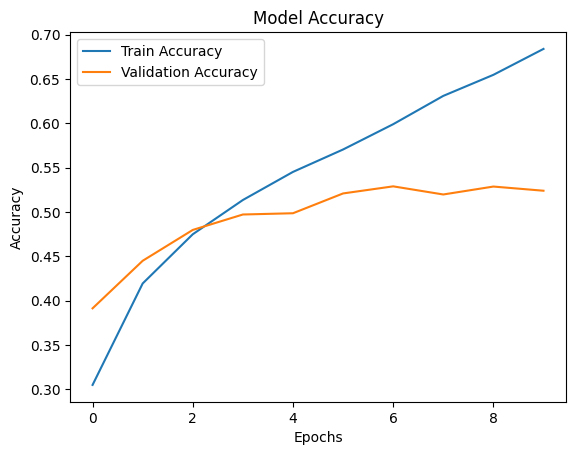

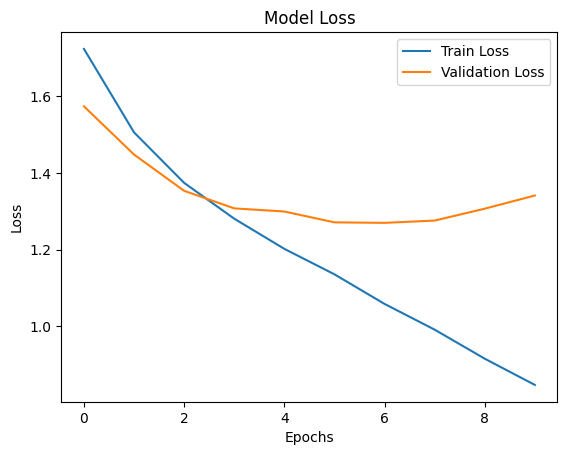

In [ ]:
# ------------------------------------------
# Plot Accuracy & Loss Graphs
# ------------------------------------------

import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


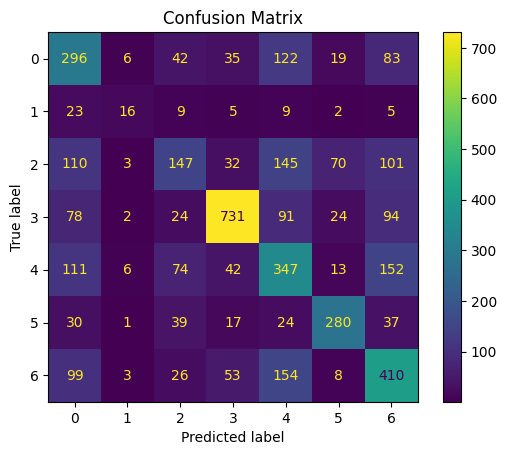

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Predictions
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_classes)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(48,48,1)),           # <-- important
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(7, activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
_ = model(X_train[:1])

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=5,                      # you can keep 5–10
    validation_data=(X_val, y_val)
)

Epoch 1/5
532/532 ━━━━━━━━━━━━━━━━━━━━ 58s 106ms/step - accuracy: 0.2991 - loss: 1.7307 - val_accuracy: 0.3936 - val_loss: 1.5669
Epoch 2/5
532/532 ━━━━━━━━━━━━━━━━━━━━ 71s 133ms/step - accuracy: 0.4202 - loss: 1.4965 - val_accuracy: 0.4607 - val_loss: 1.4100
Epoch 3/5
532/532 ━━━━━━━━━━━━━━━━━━━━ 70s 111ms/step - accuracy: 0.4826 - loss: 1.3642 - val_accuracy: 0.4847 - val_loss: 1.3584
Epoch 4/5
532/532 ━━━━━━━━━━━━━━━━━━━━ 59s 111ms/step - accuracy: 0.5176 - loss: 1.2796 - val_accuracy: 0.4965 - val_loss: 1.3169
Epoch 5/5
532/532 ━━━━━━━━━━━━━━━━━━━━ 80s 107ms/step - accuracy: 0.5395 - loss: 1.2110 - val_accuracy: 0.5078 - val_loss: 1.3021


In [ ]:
# Build the model graph
_ = model(X_val[:1], training=False)

Grad-CAM  is used to visualize the regions of the face that influence the model’s predictions. The heatmap highlights important areas such as eyes and mouth, which are critical for emotion recognition. Due to the low resolution of the dataset and moderate model accuracy, the visualization may appear less sharp.


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_10']
Received: inputs=Tensor(shape=(1, 48, 48, 1))
  warnings.warn(msg)


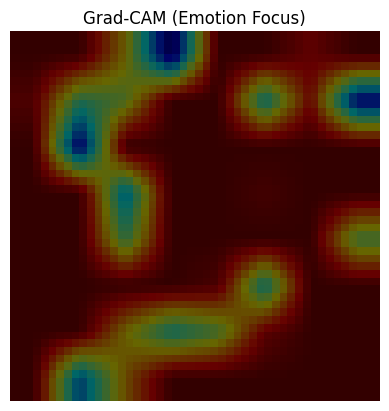

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# pick an image
img = X_val[0]
img_array = np.expand_dims(img, axis=0)

# Build graph (again, harmless if already built)
_ = model(img_array, training=False)

# Last conv layer
last_conv_layer = model.get_layer("conv2d_5")

# Grad-CAM model
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[last_conv_layer.output, model.outputs[0]]
)

# Forward + gradients
with tf.GradientTape() as tape:
    conv_out, preds = grad_model(img_array)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, conv_out)

# Global-average pool the gradients
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# Weight the conv feature maps
conv_out = conv_out[0]
heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)

# ReLU + normalize
heatmap = tf.maximum(heatmap, 0)
heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

# Resize to image size
heatmap = cv2.resize(heatmap.numpy(), (48, 48))

# Overlay
# Convert grayscale image to RGB
img_rgb = np.repeat(img, 3, axis=2)

# Normalize heatmap to 0–255
heatmap_uint8 = np.uint8(255 * heatmap)

# Apply color map
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

# Combine image + heatmap
superimposed_img = cv2.addWeighted(img_rgb.astype('uint8'), 0.6, heatmap_color, 0.4, 0)

# Show result
plt.imshow(superimposed_img)
plt.title("Grad-CAM (Emotion Focus)")
plt.axis('off')
plt.show()

**Prediction on New Images**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving img4.jpg to img4.jpg
Saving img3.jpg to img3.jpg
Saving img2.jpg to img2.jpg
Saving img1.jpg to img1.jpg


In [ ]:
import os
print(os.listdir())

['.config', 'img1.jpg', 'img3.jpg', 'img4.jpg', 'fer2013.csv', 'img2.jpg', 'sample_data']


**Prediction Analysis**

The trained model was tested on unseen facial images to evaluate its real-world performance.
The model correctly identified some emotions, while a few predictions were inaccurate due to low image resolution and similarities between facial expressions.
This demonstrates both the capability and current limitations of the model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step


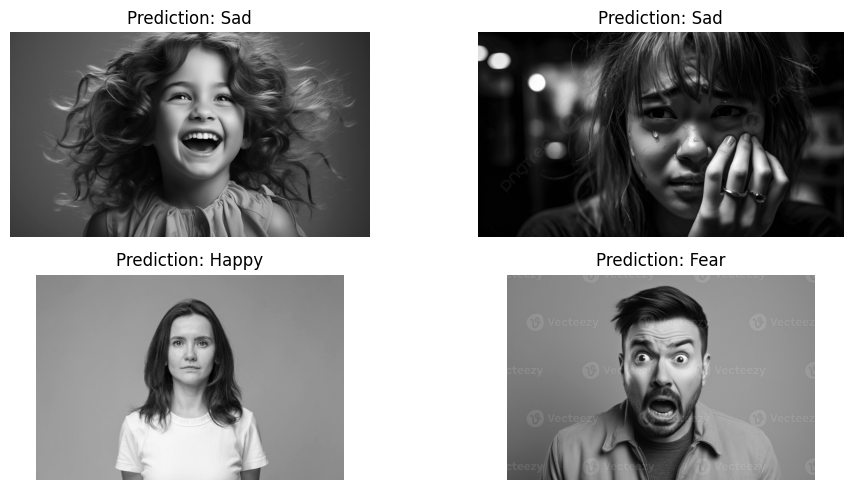

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Emotion labels
emotion_labels = [
    "Angry", "Disgust", "Fear",
    "Happy", "Sad", "Surprise", "Neutral"
]

# Function to predict emotion
def predict_emotion(image_path):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Check if image loaded
    if img is None:
        print(f"Error: Could not load {image_path}")
        return None, "Invalid Image"

    img_resized = cv2.resize(img, (48, 48))
    img_normalized = img_resized / 255.0
    img_input = np.reshape(img_normalized, (1, 48, 48, 1))

    prediction = model.predict(img_input)
    emotion = emotion_labels[np.argmax(prediction)]

    return img, emotion

# ------------------------------------------
# Test on images
# ------------------------------------------

image_paths = ["/content/img1.jpg", "/content/img2.jpg", "/content/img3.jpg", "/content/img4.jpg"]   # EXACT names

plt.figure(figsize=(10,5))

for i, path in enumerate(image_paths[:4]):  # 4 images

    img, emotion = predict_emotion(path)

    if img is None:
        continue

    plt.subplot(2, 2, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Prediction: {emotion}")
    plt.axis('off')

plt.tight_layout()
plt.show()

The model performs well on clear facial expressions such as fear and sadness, but struggles with neutral and subtle expressions. This highlights the challenge of emotion recognition and the need for more robust training data.

**Conclusion**

In this project, a CNN-based facial emotion detection system was developed using deep learning.
The model was able to classify multiple facial emotions and achieved reasonable performance on validation data.
Additional techniques such as confusion matrix analysis and Grad-CAM improved the interpretability of the system.
Future improvements can include larger datasets, deeper architectures, and real-time webcam integration for better performance.